In [1]:
import numpy as np
import torch
import random
import segmentation_models_pytorch as smp
import matplotlib.pyplot as plt

from torch import nn
from torch.utils.data import Dataset, DataLoader
from config import config
from tqdm.auto import tqdm
from utils import (
    build_metadata, split_metadata, build_dataset, preprocess_img,
    print_split_summary, count_by_class, plot_class_distribution,
)

/home/mohamed-ashraf/Desktop/projects/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
print("DEVICE:", config.DEVICE)

DEVICE: cuda


In [3]:
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)

set_seed(config.RANDOM_STATE)

In [4]:
meta = build_metadata(config.DATA_DIR / 'samples')
train_meta, val_meta, test_meta = split_metadata(meta)

print_split_summary('train', train_meta)
print_split_summary('val', val_meta)
print_split_summary('test', test_meta)

Scanning masks:   0%|          | 0/559 [00:00<?, ?it/s]

Scanning masks: 100%|██████████| 559/559 [00:00<00:00, 633.49it/s]


[train] images: 447
  Unknown  pixels=  229,585 images=111
  Greenery pixels=8,257,143 images=268
  Sand     pixels=18,622,508 images=402
  Water    pixels=10,206,745 images=311
  Cement   pixels=9,019,840 images=304
  strata: {'base__w_0__c_0': 74, 'water_and_cement__w_gt_10k__c_gt_10k': 68, 'water_only__w_gt_10k__c_0': 65, 'water_and_cement__w_1k_10k__c_gt_10k': 60, 'cement_only__w_0__c_gt_10k': 36, 'water_and_cement__w_101_1k__c_gt_10k': 27, 'water_and_cement__w_gt_10k__c_1k_10k': 25, 'water_and_cement__w_1_100__c_gt_10k': 23, 'cement_only__w_0__c_1k_10k': 14, 'water_and_cement__w_gt_10k__c_101_1k': 10, 'cement_only__w_0__c_101_1k': 8, 'water_and_cement__w_101_1k__c_1k_10k': 7, 'water_and_cement__w_gt_10k__c_1_100': 6, 'water_and_cement__w_1_100__c_1k_10k': 6, 'water_and_cement__w_1k_10k__c_1k_10k': 4, 'cement_only__w_0__c_1_100': 4, 'water_and_cement': 3, 'water_and_cement__w_1k_10k__c_101_1k': 3, 'water_only__w_1k_10k__c_0': 2, 'water_only': 2}
[val] images: 56
  Unknown  pixels= 

In [5]:
class LandCoverSegDataset(Dataset):
    def __init__(self, X, y, transform=None):
        self.X = X
        self.y = y
        self.transform = transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        img = self.X[idx].astype(np.float32)
        mask = self.y[idx].astype(np.int64)

        if self.transform is not None:
            img, mask = self.transform(img, mask)

        img = np.ascontiguousarray(img)
        mask = np.ascontiguousarray(mask)
        return torch.from_numpy(img), torch.from_numpy(mask)

In [6]:
def process_pair(img_path, mask_path, train=False):
    img, mask, pixel_valid = preprocess_img(img_path, mask_path, train=train)
    img = img.astype(np.float32)
    mask = mask.astype(np.uint8).copy()
    
    if train:
        valid = pixel_valid & (mask != 0)
        mask[~valid] = 0

    return img, mask, None


def concatenate(results, target_size=(256, 256)):
    X_parts = []
    y_parts = []
    for X, y, _ in results:
        channels, h, w = X.shape
        th, tw = target_size
        ch = min(h, th)
        cw = min(w, tw)
        cropped_X = X[:, :ch, :cw]
        cropped_y = y[:ch, :cw]
        padded_X = np.zeros((channels, th, tw), dtype=X.dtype)
        padded_y = np.zeros((th, tw), dtype=y.dtype)
        padded_X[:, :ch, :cw] = cropped_X
        padded_y[:ch, :cw] = cropped_y
        X_parts.append(padded_X)
        y_parts.append(padded_y)

    return np.stack(X_parts, axis=0), np.stack(y_parts, axis=0), None

Building dataset: 100%|██████████| 56/56 [00:00<00:00, 168.13it/s]


Train full: (447, 12, 256, 256) {'Greenery': 5340937, 'Sand': 11617563, 'Water': 6469453, 'Cement': 5663681}
Val full  : (56, 12, 256, 256) {'Greenery': 666160, 'Sand': 1457013, 'Water': 763693, 'Cement': 780697}
Test full : (56, 12, 256, 256) {'Greenery': 746053, 'Sand': 1515420, 'Water': 747567, 'Cement': 635727}
Ignored train pixels: 202958


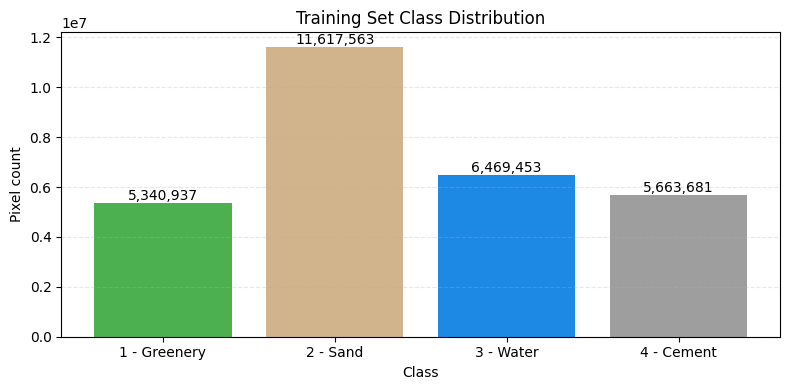

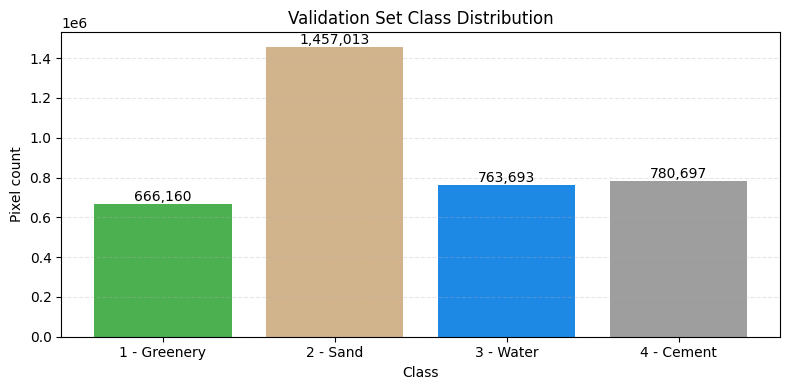

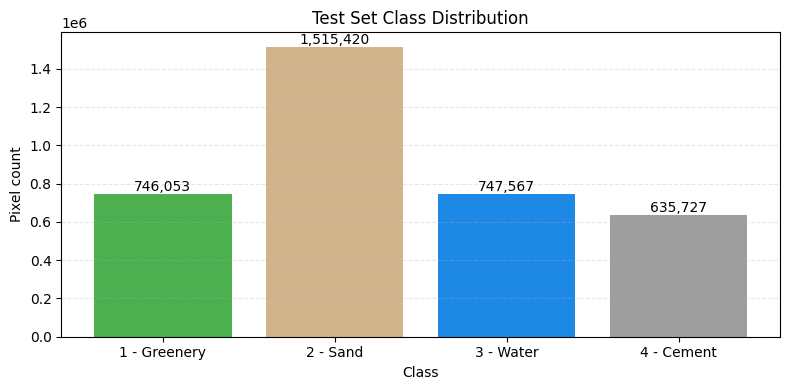

In [7]:
X_train, y_train, _ = build_dataset(train_meta, process_pair, concatenate, train=True)
X_val, y_val, _ = build_dataset(val_meta, process_pair, concatenate)
X_test, y_test, _ = build_dataset(test_meta, process_pair, concatenate)

print('Train full:', X_train.shape, count_by_class(y_train[y_train != 0]))
print('Val full  :', X_val.shape, count_by_class(y_val[y_val != 0]))
print('Test full :', X_test.shape, count_by_class(y_test[y_test != 0]))

train_valid = y_train != 0
val_valid = y_val != 0
test_valid = y_test != 0

print('Ignored train pixels:', int((~train_valid).sum()))
plot_class_distribution(y_train[train_valid], 'Training Set Class Distribution')
plot_class_distribution(y_val[val_valid], 'Validation Set Class Distribution')
plot_class_distribution(y_test[test_valid], 'Test Set Class Distribution')

In [8]:
class SatelliteTrainTransform:
    def __init__(
        self,
        hflip_p=0.5,
        vflip_p=0.5,
        rotate_p=0.75,
        transpose_p=0.25,
        noise_p=0.15,
        intensity_p=0.30,
        gamma_p=0.10,
        noise_std=0.004,
        gain_range=(0.97, 1.03),
        bias_range=(-0.01, 0.01),
        gamma_range=(0.97, 1.03),
    ):
        self.hflip_p = hflip_p
        self.vflip_p = vflip_p
        self.rotate_p = rotate_p
        self.transpose_p = transpose_p
        self.noise_p = noise_p
        self.intensity_p = intensity_p
        self.gamma_p = gamma_p
        self.noise_std = noise_std
        self.gain_range = gain_range
        self.bias_range = bias_range
        self.gamma_range = gamma_range

    def __call__(self, img, mask):
        if random.random() < self.hflip_p:
            img = np.flip(img, axis=2)
            mask = np.flip(mask, axis=1)

        if random.random() < self.vflip_p:
            img = np.flip(img, axis=1)
            mask = np.flip(mask, axis=0)

        if random.random() < self.rotate_p:
            k = random.randint(1, 3)
            img = np.rot90(img, k=k, axes=(1, 2))
            mask = np.rot90(mask, k=k, axes=(0, 1))

        if random.random() < self.transpose_p:
            img = np.transpose(img, (0, 2, 1))
            mask = np.transpose(mask, (1, 0))

        if random.random() < self.intensity_p:
            gain = np.random.uniform(*self.gain_range, size=(img.shape[0], 1, 1)).astype(np.float32)
            bias = np.random.uniform(*self.bias_range, size=(img.shape[0], 1, 1)).astype(np.float32)
            img = np.clip(img * gain + bias, 0.0, 1.0)

        if random.random() < self.gamma_p:
            gamma = np.float32(np.random.uniform(*self.gamma_range))
            img = np.clip(img, 0.0, 1.0) ** gamma

        if random.random() < self.noise_p:
            noise = np.random.normal(0.0, self.noise_std, size=img.shape).astype(np.float32)
            img = np.clip(img + noise, 0.0, 1.0)

        return img.astype(np.float32), mask.astype(np.int64)


train_transform = SatelliteTrainTransform()

train_ds = LandCoverSegDataset(X_train, y_train, transform=train_transform)
val_ds   = LandCoverSegDataset(X_val, y_val)
test_ds  = LandCoverSegDataset(X_test, y_test)


train_loader = DataLoader(
    train_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=True,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

val_loader = DataLoader(
    val_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

test_loader = DataLoader(
    test_ds,
    batch_size=config.BATCH_SIZE,
    shuffle=False,
    num_workers=config.NUM_WORKERS,
    pin_memory=True,
)

print('Dataset sizes:', len(train_ds), len(val_ds), len(test_ds))
print('Train images with cement:', int(train_meta['has_cement'].sum()))
print('Train images with water :', int(train_meta['has_water'].sum()))


Dataset sizes: 447 56 56
Train images with cement: 304
Train images with water : 311


In [9]:
class SEBlock(nn.Module):
    def __init__(self, channels, reduction=4):
        super().__init__()
        hidden = max(channels // reduction, 4)
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.fc = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=1),
            nn.ReLU(inplace=True),
            nn.Conv2d(hidden, channels, kernel_size=1),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return x * self.fc(self.pool(x))


class SpectralStem(nn.Module):
    def __init__(self, channels=12, hidden=64, dropout=0.1):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(channels, hidden, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout),

            nn.Conv2d(hidden, hidden, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(hidden),
            nn.ReLU(inplace=True),

            nn.Conv2d(hidden, channels, kernel_size=1, bias=False),
            nn.BatchNorm2d(channels),
        )
        self.se = SEBlock(channels)
        self.act = nn.ReLU(inplace=True)

    def forward(self, x):
        out = self.block(x)
        out = self.se(out)
        return self.act(x + out)


class UNet(nn.Module):
    def __init__(self, encoder_name="resnet34", num_classes=5):
        super().__init__()
        self.stem = SpectralStem(channels=12, hidden=64, dropout=0.1)
        self.unet = smp.Unet(
            encoder_name=encoder_name,
            encoder_weights=None,
            in_channels=12,
            classes=num_classes,
        )

    def forward(self, x):
        x = self.stem(x)
        return self.unet(x)


def compute_class_weights(y, num_classes, ignore_index=0, power=0.35, min_weight=0.80, max_weight=1.20):
    labels = y[y != ignore_index]
    counts = np.bincount(labels.reshape(-1), minlength=num_classes).astype(np.float64)

    weights = np.zeros(num_classes, dtype=np.float32)
    valid_classes = np.arange(num_classes) != ignore_index
    valid_classes &= counts > 0

    inv_freq = 1.0 / np.power(counts[valid_classes], power)
    inv_freq = inv_freq / inv_freq.mean()
    inv_freq = np.clip(inv_freq, min_weight, max_weight)
    weights[valid_classes] = inv_freq.astype(np.float32)
    weights[ignore_index] = 0.0
    return torch.tensor(weights, dtype=torch.float32, device=config.DEVICE), counts.astype(np.int64)


model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)

CEMENT_CLASS_ID = 4
CEMENT_WEIGHT_BOOST = 1.5

optimizer = torch.optim.AdamW(model.parameters(), lr=config.LR, weight_decay=1e-4)
class_weights, class_pixel_counts = compute_class_weights(
    y_train,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
    power=0.35,
    min_weight=0.80,
    max_weight=1.20,
)
class_weights[CEMENT_CLASS_ID] *= CEMENT_WEIGHT_BOOST

criterion = nn.CrossEntropyLoss(
    weight=class_weights,
    ignore_index=config.IGNORE_INDEX,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=5,
)

print(sum(p.numel() for p in model.parameters()) / 1e6, "M parameters")
print("Class pixel counts:")
for cls in range(config.NUM_CLASSES):
    print(f"  {config.CLASS_NAMES[cls]} ({cls}): {int(class_pixel_counts[cls]):,}")
print("Loss class weights:")
for cls, weight in enumerate(class_weights.detach().cpu().numpy()):
    print(f"  {config.CLASS_NAMES[cls]} ({cls}): {weight:.4f}")


24.510109 M parameters
Class pixel counts:
  Unknown (0): 0
  Greenery (1): 5,340,937
  Sand (2): 11,617,563
  Water (3): 6,469,453
  Cement (4): 5,663,681
Loss class weights:
  Unknown (0): 0.0000
  Greenery (1): 1.0879
  Sand (2): 0.8289
  Water (3): 1.0174
  Cement (4): 1.5988


In [10]:
images, masks = next(iter(train_loader))
images = images.to(config.DEVICE)
masks = masks.to(config.DEVICE)

with torch.no_grad():
    out = model(images)

print("Input shape :", images.shape)
print("Mask shape  :", masks.shape)
print("Output shape:", out.shape)

Input shape : torch.Size([8, 12, 256, 256])
Mask shape  : torch.Size([8, 256, 256])
Output shape: torch.Size([8, 5, 256, 256])


In [11]:
def compute_dataset_iou(conf_mat, ignore_index=0):
    ious = []

    for cls in range(conf_mat.shape[0]):
        if cls == ignore_index:
            continue

        tp = conf_mat[cls, cls]
        fp = conf_mat[:, cls].sum() - tp
        fn = conf_mat[cls, :].sum() - tp
        union = tp + fp + fn

        if union > 0:
            ious.append(tp / union)

    return float(np.mean(ious)) if ious else 0.0


def train_one_epoch(model, loader, optimizer, criterion, device):
    model.train()
    total_loss = 0.0

    for images, masks in tqdm(loader, desc='Training'):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad(set_to_none=True)
        logits = model(images)
        loss = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return total_loss / len(loader)


@torch.no_grad()
def validate(model, loader, criterion, device, num_classes=5, ignore_index=0):
    model.eval()
    total_loss = 0.0
    conf_mat = np.zeros((num_classes, num_classes), dtype=np.int64)

    for images, masks in loader:
        images = images.to(device)
        masks = masks.to(device)

        logits = model(images)
        loss = criterion(logits, masks)

        preds = torch.argmax(logits, dim=1)
        valid = masks != ignore_index
        preds_valid = preds[valid]
        masks_valid = masks[valid]

        if masks_valid.numel() > 0:
            indices = (masks_valid.view(-1) * num_classes + preds_valid.view(-1)).to(torch.int64)
            batch_conf = torch.bincount(indices, minlength=num_classes * num_classes)
            conf_mat += batch_conf.reshape(num_classes, num_classes).cpu().numpy()

        total_loss += loss.item()

    mean_loss = total_loss / len(loader)
    mean_iou = compute_dataset_iou(conf_mat, ignore_index=ignore_index)
    return mean_loss, mean_iou, conf_mat

In [12]:
num_epochs = 100
early_stopping_patience = 50
best_val_iou = -1.0
epochs_without_improvement = 0

for epoch in range(num_epochs):
    train_loss = train_one_epoch(model, train_loader, optimizer, criterion, config.DEVICE)
    val_loss, val_iou, val_conf_mat = validate(
        model,
        val_loader,
        criterion,
        config.DEVICE,
        num_classes=config.NUM_CLASSES,
        ignore_index=config.IGNORE_INDEX,
    )
    scheduler.step(val_iou)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f"Epoch {epoch+1}/{num_epochs} | "
        f"train_loss={train_loss:.4f} | "
        f"val_loss={val_loss:.4f} | "
        f"val_mIoU={val_iou:.4f} | "
        f"lr={current_lr:.2e}"
    )

    if val_iou > best_val_iou + 1e-4:
        best_val_iou = val_iou
        epochs_without_improvement = 0
        torch.save(model.state_dict(), "best_unet.pth")
        print("Saved best model")
    else:
        epochs_without_improvement += 1
        if epochs_without_improvement >= early_stopping_patience:
            print("Early stopping triggered")
            break

Training: 100%|██████████| 56/56 [00:09<00:00,  5.61it/s]


Epoch 1/100 | train_loss=0.9342 | val_loss=0.4952 | val_mIoU=0.7619 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 56/56 [00:09<00:00,  5.75it/s]


Epoch 2/100 | train_loss=0.6089 | val_loss=0.3761 | val_mIoU=0.7792 | lr=3.00e-04
Saved best model


Training: 100%|██████████| 56/56 [00:09<00:00,  5.75it/s]


...

Epoch 98/100 | train_loss=0.1738 | val_loss=0.1587 | val_mIoU=0.8835 | lr=1.17e-06


Training: 100%|██████████| 56/56 [00:09<00:00,  5.70it/s]


Epoch 99/100 | train_loss=0.1589 | val_loss=0.1625 | val_mIoU=0.8816 | lr=1.17e-06


Training: 100%|██████████| 56/56 [00:09<00:00,  5.69it/s]


Epoch 100/100 | train_loss=0.1636 | val_loss=0.1703 | val_mIoU=0.8804 | lr=1.17e-06


In [13]:
checkpoint = torch.load("best_unet.pth", map_location=config.DEVICE)
model = UNet(
    encoder_name="resnet34",
    num_classes=5
).to(config.DEVICE)
model.load_state_dict(checkpoint)
model.eval()

UNet(
  (stem): SpectralStem(
    (block): Sequential(
      (0): Conv2d(12, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Dropout2d(p=0.1, inplace=False)
      (4): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (6): ReLU(inplace=True)
      (7): Conv2d(64, 12, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (8): BatchNorm2d(12, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (se): SEBlock(
      (pool): AdaptiveAvgPool2d(output_size=1)
      (fc): Sequential(
        (0): Conv2d(12, 4, kernel_size=(1, 1), stride=(1, 1))
        (1): ReLU(inplace=True)
        (2): Conv2d(4, 12, kernel_size=(1, 1), stride=(1, 1))
        (3): Sigmoid()
      )
    )
    (act): ReLU(inplace=True)

In [14]:
val_loss, val_iou, val_conf_mat = validate(
    model,
    val_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Validation | loss={val_loss:.4f} | mIoU={val_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = val_conf_mat[cls, cls]
    fp = val_conf_mat[:, cls].sum() - tp
    fn = val_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Validation | loss=0.1591 | mIoU=0.8835
  Greenery IoU: 0.9015
  Sand IoU: 0.8882
  Water IoU: 0.9247
  Cement IoU: 0.8197


In [15]:
test_loss, test_iou, test_conf_mat = validate(
    model,
    test_loader,
    criterion,
    config.DEVICE,
    num_classes=config.NUM_CLASSES,
    ignore_index=config.IGNORE_INDEX,
)
print(f"Test | loss={test_loss:.4f} | mIoU={test_iou:.4f}")

for cls in range(config.NUM_CLASSES):
    if cls == config.IGNORE_INDEX:
        continue

    tp = test_conf_mat[cls, cls]
    fp = test_conf_mat[:, cls].sum() - tp
    fn = test_conf_mat[cls, :].sum() - tp
    union = tp + fp + fn
    class_iou = tp / union if union > 0 else float('nan')
    print(f"  {config.CLASS_NAMES[cls]} IoU: {class_iou:.4f}")

Test | loss=0.1278 | mIoU=0.9061
  Greenery IoU: 0.9138
  Sand IoU: 0.9303
  Water IoU: 0.9584
  Cement IoU: 0.8218


In [16]:
@torch.no_grad()
def show_prediction(model, split_df, idx=0):
    if isinstance(model, dict):
        loaded_model = UNet(
            encoder_name="resnet34",
            num_classes=5
        ).to(config.DEVICE)
        loaded_model.load_state_dict(model)
        model = loaded_model

    model.eval()

    row = split_df.iloc[idx]
    image_np, mask_np, _ = preprocess_img(row["img_path"], row["mask_path"], ml="dl")

    x = torch.from_numpy(image_np.astype(np.float32)).unsqueeze(0).to(config.DEVICE)

    logits = model(x)
    pred = torch.argmax(logits, dim=1).squeeze(0).cpu().numpy()

    mask_values, mask_counts = np.unique(mask_np, return_counts=True)
    pred_values, pred_counts = np.unique(pred, return_counts=True)

    print("Mask: ", dict(zip(mask_values, mask_counts)))
    print("Prediction: ", dict(zip(pred_values, pred_counts)))

    rgb = np.transpose(image_np[[3, 2, 1]], (1, 2, 0))
    rgb = np.clip(rgb * 3.0, 0, 1)

    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    plt.imshow(rgb)
    plt.title("RGB")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(mask_np, cmap="tab10", vmin=0, vmax=4)
    plt.title("Ground Truth")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(pred, cmap="tab10", vmin=0, vmax=4)
    plt.title("Prediction")
    plt.axis("off")

    plt.show()


Mask:  {np.uint8(1): np.int64(1535), np.uint8(2): np.int64(80700), np.uint8(3): np.int64(16877), np.uint8(4): np.int64(5380)}
Prediction:  {np.int64(1): np.int64(2074), np.int64(2): np.int64(81024), np.int64(3): np.int64(18666), np.int64(4): np.int64(2728)}


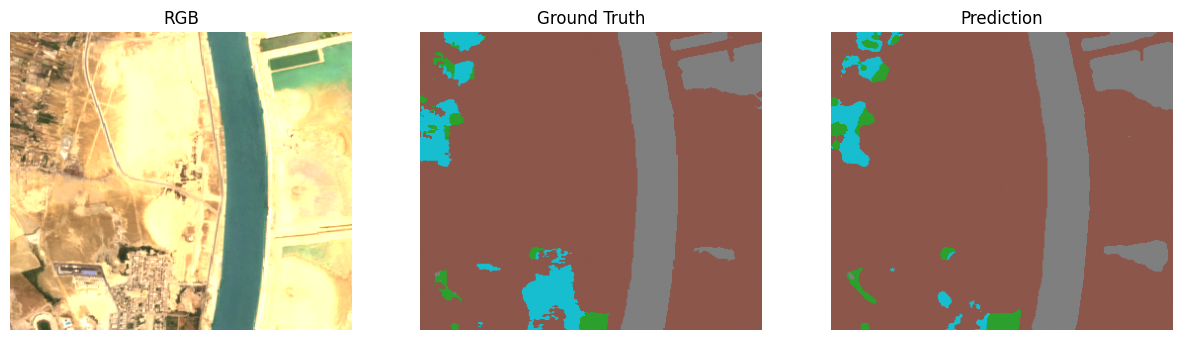

In [17]:
show_prediction(model, test_meta, idx=12)